# **CEM & CBM: Practice**

Hi, everyone!
The practice on CBM and CEM will be aimed at understanding the theory behind these models. Throughout the practice, we will rely on the paper [Concept Embedding Models:
Beyond the Accuracy-Explainability Trade-Off](https://arxiv.org/pdf/2209.09056) and on the examples attached to the documentation of the [pyTorch explain](https://pytorch-explain.readthedocs.io/en/latest/index.html#) library.

During the practice, you will:

*   Explore the capabilities of the pyTorch explain library
*   Look at and implement CBM and CEM models
*   Use the models you build to solve the trigonometric and the XOR tasks

Happy coding!

![Bootle](https://ucarecdn.com/ddf09dc0-e603-4943-b756-77ba9204f84d/)

## PyTorch, Explain!

PyTorch, Explain! is a library that extends the capabilities of PyTorch for developing explainable deep learning models. The library contains:

- Specific loss functions, metrics and layers for embedding concepts into a model
- Wrappers for interpreting models built on top of concepts
- Datasets (benchmarks) for evaluating concept-based models

The library does not contain gradient-based or other classical interpretation methods, so it can only be useful in the scenario of developing concept-based networks (Deep Concept Reasoners, CEM, CBM and Logic Explained Nets). In this practice we will work with CBM and CEM.

In [ ]:
!pip install torch-explain -q # Install pytorch-explain

## Datasets.

Labelling concepts, as we discussed in the module, is time-consuming. That is why we will use the already prepared XOR and Dot benchmarks to evaluate the models.


**XOR data**

To make the classical task harder, the XOR dataset uses as input features a continuous pair of values $(x_1, x_2)$ from the interval $[0, 1]$. The concepts in this task are boolean vectors built by the rule $(Bool(c_1 > 0.5), Bool(c_2 > 0.5))$


**Dot data**

A dataset that is created as follows:
1. Take 4 vectors $v_1, v_2, w_1, w_2 ∈ R^2$, where w_1 = (1, 1), w_2 = (-1, -1)
2. From them an object is built: $x = (x_1, x_2, x_3, x_4): x_1, x_2 =  v_1 + v_2, x_3, x_4 = v_1 - v_2$
2. Based on the vectors taken, two concept annotations are generated, indicating whether $v_i, w_i$ point in the same direction.
3. The target variable $y$ is the answer to the question of whether $v_1$, $v_2$ point (practically) in the same direction

**Materials, in case you like these models:**

- The [repository](https://github.com/yewsiang/ConceptBottleneck) with the code from the original paper [Concept Bottleneck Models](https://arxiv.org/pdf/2007.04612)
- An [implementation](https://github.com/mateoespinosa/cem/tree/main) of CEM based on the architecture papers from NeurIPS 2022
- For deeper [practice](https://github.com/Trustworthy-ML-Lab/Label-free-CBM/tree/main) with CBM, based on the paper [Label-free Concept Bottleneck Models](https://openreview.net/pdf?id=FlCg47MNvBA)

Let us import the libraries we need for the work.

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


import random
import numpy as np

import torch_explain as te
from torch_explain import datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


# Let us load the first dataset for the practice right away
x_xor, c_xor, y_xor = datasets.xor(500)
x_xor_train, x_xor_test, c_xor_train, c_xor_test, y_xor_train, y_xor_test = train_test_split(x_xor, c_xor, y_xor,
                                                                            test_size=0.33,
                                                                            random_state=42)

**Concept Bottleneck Models**

Let us recall what a CBM looks like:

![CBM_model](https://ucarecdn.com/96ae12f2-d0db-4d7e-851b-7240178c5593/-/crop/2303x803/24,0/-/preview/)


Mathematically, a CBM is a combination of two functions, $y = f(g(x)),$ where $g(x)$ is the function that maps every input object to a vector of concepts (`concept_encoder`), and $f(g(x))$ is the function that maps every vector of concepts to the target answer (`task_predictor`).

The architecture of both the `concept_encoder` and the `task_predictor` can be anything, but overall these are the two mandatory building blocks of a CBM model.  

**Complete the model by filling in the dimensions correctly. What are the Task and Concept accuracy?**

In [ ]:
#Let us fix all the seeds for reproducibility of the results

np.random.seed(0)
random.seed(0)
torch.manual_seed(0)


class Concept_Bottleneck_Model(nn.Module): # Initialization of the CBM model

  def __init__(self, input_size, hidden_size, concept_size, len_out):
    super(Concept_Bottleneck_Model, self).__init__()

    # Part 1: concept encoder
    self.concept_encoder = torch.nn.Sequential(torch.nn.Linear(input_size, hidden_size), # Linear layer
                                               torch.nn.LeakyReLU(), # Activation function with
                                               torch.nn.Linear("", 8), # PUT THE DIMENSION HERE
                                               torch.nn.LeakyReLU(),
                                               torch.nn.Linear("", concept_size), # PUT THE DIMENSION HERE
                                               torch.nn.Sigmoid())
    # Part 2: task predictor
    self.task_predictor = torch.nn.Sequential(torch.nn.Linear("", 4), # PUT THE DIMENSION HERE
                                               torch.nn.LeakyReLU(),
                                               torch.nn.Linear(4, len_out))

  def forward(self, input):

    c_pred = self.concept_encoder(input)
    y_pred = self.task_predictor(c_pred)

    return c_pred, y_pred

Now let us train the model on the dataset we imported.

In [ ]:
# Let us define the initialized model
XOR_CBM = Concept_Bottleneck_Model(x_xor.shape[1], 16, c_xor.shape[1], 1)

# Let us define the loss functions for the concepts and the classes, as well as the optimizer

optimizer = torch.optim.AdamW(XOR_CBM.parameters(), lr=0.01)
loss_form_c = torch.nn.BCELoss()
loss_form_y = torch.nn.BCEWithLogitsLoss()

# switch to train mode
XOR_CBM.train()

for epoch in range(2001):
    optimizer.zero_grad()

    # predict the concepts and the task
    c_xor_pred = XOR_CBM.concept_encoder(x_xor_train)
    y_xor_pred = XOR_CBM.task_predictor(c_xor_pred)

    # update the loss functions (do not change the coefficient)
    concept_loss = loss_form_c(c_xor_pred, c_xor_train)
    task_loss = loss_form_y(y_xor_pred, y_xor_train)
    loss = concept_loss + 0.2*task_loss

    loss.backward()
    optimizer.step()

And let us solve the task! Do not forget to submit your answers in the trainer.

In [ ]:
c_xor_pred = XOR_CBM.concept_encoder(x_xor_test) # predict the concepts
y_xor_pred = XOR_CBM.task_predictor(c_xor_pred) # predict the solution of the task

concept_xor_accuracy = accuracy_score(c_xor_test, c_xor_pred > 0.5)
task_xor_accuracy = accuracy_score(y_xor_test, y_xor_pred > 0)

print(f'Concept accuracy: {concept_xor_accuracy}\n Task accuracy: {task_xor_accuracy}')

In [ ]:
# Let us evaluate how the model works on the concept pairs (1, 0), (0, 1), (1, 1), (0, 0)

c_different = torch.FloatTensor([0, 1])
print(f"f({c_different}) = {int(XOR_CBM.task_predictor(c_different).item() > 0)}")

c_different2 = torch.FloatTensor([1, 0])
print(f"f({c_different2}) = {int(XOR_CBM.task_predictor(c_different2).item() > 0)}")

c_equal = torch.FloatTensor([1, 1])
print(f"f({c_equal}) = {int(XOR_CBM.task_predictor(c_equal).item() > 0)}")

c_equal0 = torch.FloatTensor([0, 0])
print(f"f({c_equal0}) = {int(XOR_CBM.task_predictor(c_equal0).item() > 0)}")

After training, the behaviour of the model is transparent: we understand that it outputs one when the concept values differ and 0 when the input concepts are different. Great job!

Besides that, pay attention to the training process — the update of the error function depends only on 0.2 of the `task_loss`, so we put more emphasis on the concepts. What happens if we swap this around?

In [ ]:
XOR_CBM = Concept_Bottleneck_Model(x_xor.shape[1], 16, c_xor.shape[1], 1)

optimizer = torch.optim.AdamW(XOR_CBM.parameters(), lr=0.01)
loss_form_c = torch.nn.BCELoss()
loss_form_y = torch.nn.BCEWithLogitsLoss()

XOR_CBM.train()

for epoch in range(2001):
    optimizer.zero_grad()

    # predict the concepts and the task
    c_xor_pred = XOR_CBM.concept_encoder(x_xor_train)
    y_xor_pred = XOR_CBM.task_predictor(c_xor_pred)

    # update the loss functions (do not change the coefficient)
    concept_loss = loss_form_c(c_xor_pred, c_xor_train)
    task_loss = loss_form_y(y_xor_pred, y_xor_train)
    loss = 0.2*concept_loss + task_loss

    loss.backward()
    optimizer.step()

In [ ]:
c_xor_pred = XOR_CBM.concept_encoder(x_xor_test)
y_xor_pred = XOR_CBM.task_predictor(c_xor_pred)

concept_xor_accuracy = accuracy_score(c_xor_test, c_xor_pred > 0.5)
task_xor_accuracy = accuracy_score(y_xor_test, y_xor_pred > 0)

print(f'Concept accuracy: {concept_xor_accuracy}\n Task accuracy: {task_xor_accuracy}')

The accuracy for the task and for the concepts has not changed significantly. It looks as if the coefficients in front of the loss make no difference (you will see this for yourself if you run the training process with various combinations), but this fact holds only for this task — it is a simple one. Let us look at training a CBM on a harder task — we will use the dot dataset.

You can also check this yourself, but if you run the training with successively different contributions of the `concept` and `task_loss` for the `dot data` set, the accuracy of both tasks will change within ranges that go from mild to significant.

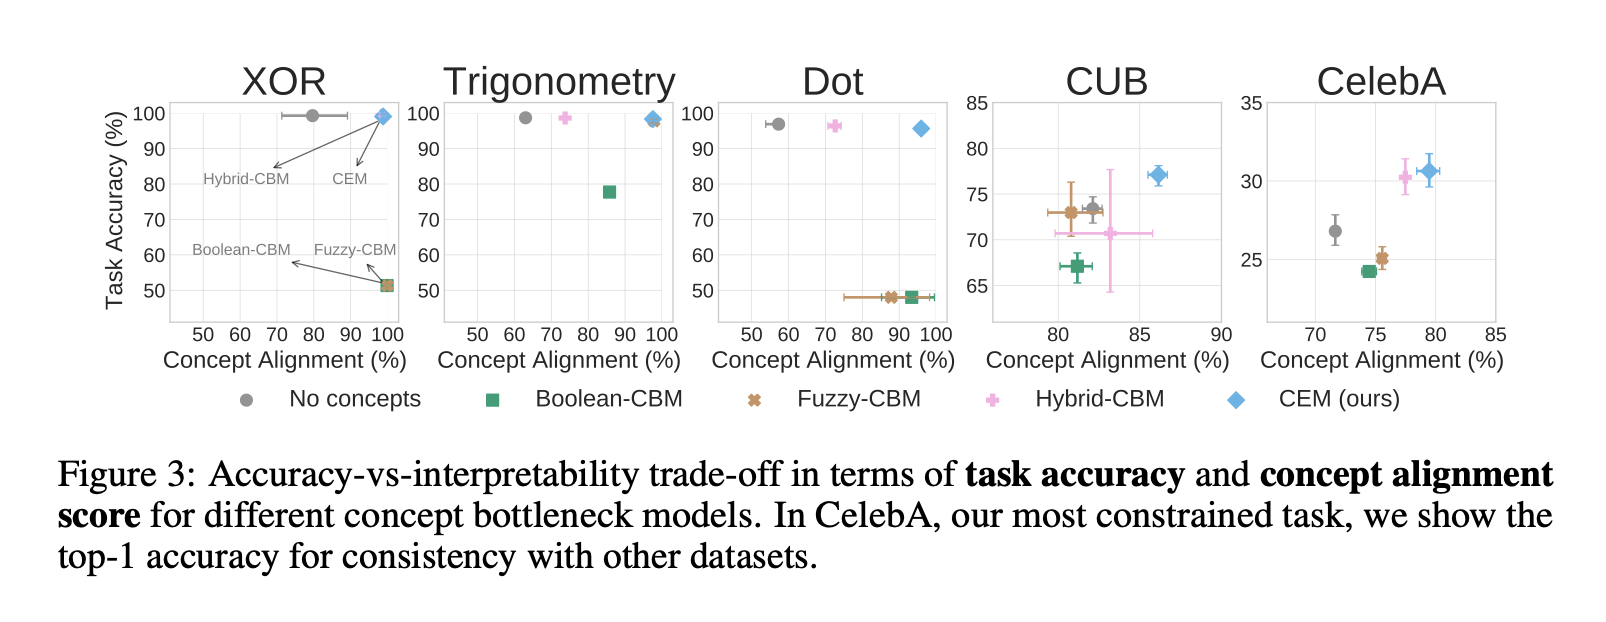
[Source](https://arxiv.org/pdf/2209.09056)

This phenomenon is called the ***accuracy-explainability trade-off***. When a researcher strives for higher accuracy, the explanations provided by the models tend to degrade in quality and correctness, and vice versa. Moving from Concept Bottleneck Models to Concept Embedding Models partially solves this problem.

In the next part of the practice you will see this for yourself by comparing the performance of CBM and CEM on the dot dataset on your own.

**Look at the code that generates dot_data in the trainer. Which parts of the plane do the concepts in dot data separate?**

In [ ]:
#Let us load the dataset and split it into the training and the test samples

x_dot, c_dot, y_dot = datasets.dot(500)
x_dot_train, x_dot_test, c_dot_train, c_dot_test, y_dot_train, y_dot_test = train_test_split(x_dot, c_dot, y_dot,
                                                                     test_size=0.33, random_state=42)

Let us train a concept-based model with the best combination of concept and task losses. **Choose it in the trainer, check your answer and train the model.**

In [ ]:
DOT_CBM = Concept_Bottleneck_Model(x_dot.shape[1], 16, c_dot.shape[1], 1)

optimizer = torch.optim.AdamW(DOT_CBM.parameters(), lr=0.01)
loss_form_c = torch.nn.BCELoss()
loss_form_y = torch.nn.BCEWithLogitsLoss()

DOT_CBM.train()

for epoch in range(2001):

  optimizer.zero_grad()

  # predict the concepts and the task
  c_dot_pred = DOT_CBM.concept_encoder(x_dot_train)
  y_dot_pred = DOT_CBM.task_predictor(c_dot_pred)

  # update the loss functions (do not change the coefficient)
  concept_loss = loss_form_c(c_dot_pred, c_dot_train)
  task_loss = loss_form_y(y_dot_pred, y_dot_train)
  loss = #YOUR_COEFF*concept_loss + task_loss

  loss.backward()
  optimizer.step()

In [ ]:
c_dot_pred = DOT_CBM.concept_encoder(x_dot_test)
y_dot_pred = DOT_CBM.task_predictor(c_dot_pred)

concept_dot_accuracy = accuracy_score(c_dot_test, c_dot_pred > 0.5)
task_dot_accuracy = accuracy_score(y_dot_test, y_dot_pred > 0)

print(f'Concept accuracy: {concept_dot_accuracy}\n Task accuracy: {task_dot_accuracy}')

The concept accuracy can be called unsatisfactory, although the model solves the task quite tolerably.

## From CBM to CEM
Let us create a Concept Embedding Model class. The structure of this model is somewhat different from the structure of a CBM.

![CBM](https://ucarecdn.com/9626f7a1-c054-4f97-86da-50fb7f61b778/)

**There are similar approaches in machine learning — when with one model we predict some variable in a task, and then obtain the prediction with the help of another one, a meta-model. What are these approaches called?**

On the one hand, you can wire this structure into the model yourself. On the other hand, thanks to the capabilities of the pytorchExplain! library this can be done by adding the part `te.nn.ConceptEmbedding(10, concept_size, embedding_size)` to the model

In [ ]:
class Concept_Embedding_Model(nn.Module): #  Let us create the CEM class

  def __init__(self, input_size, hidden_size, concept_size, embedding_size, len_out):
    super(Concept_Embedding_Model, self).__init__()

    # Part 1 + 2: latent code + Concept Embedding generator
    self.latetnt_code = torch.nn.Sequential(torch.nn.Linear(input_size, hidden_size),
                                               torch.nn.LeakyReLU(),
                                               torch.nn.Linear(hidden_size, 10),
                                               torch.nn.LeakyReLU(),
                                               te.nn.ConceptEmbedding(10, concept_size, embedding_size), # add the layer responsible for the concept embeddings
                                               )
    # Part 2: task predictor
    self.task_predictor = torch.nn.Sequential(torch.nn.Linear(concept_size*embedding_size, 5),
                                               torch.nn.LeakyReLU(),
                                               torch.nn.Linear(5, len_out))

  def forward(self, input):

    c_emd, c_pred  = self.latetnt_code(input)
    y_pred = self.task_predictor(c_pred)

    return c_emd, c_pred, y_pred

Let us train our CEM and check the quality.

In [ ]:
CEM = Concept_Embedding_Model(x_dot.shape[1], 16, c_dot.shape[1], 8, 1)

optimizer = torch.optim.AdamW(CEM.parameters(), lr=0.01)
loss_form_c = torch.nn.BCELoss()
loss_form_y = torch.nn.BCEWithLogitsLoss()
CEM.train()
for epoch in range(2001):
    optimizer.zero_grad()

    # predict the embeddings and the concept labels
    c_emb, c_pred = CEM.latetnt_code(x_dot_train)
    y_pred = CEM.task_predictor(c_emb.reshape(len(c_emb), -1))

    # compute the loss function
    concept_loss = loss_form_c(c_pred, c_dot_train)
    task_loss = loss_form_y(y_pred, y_dot_train)
    loss = concept_loss + 0.3*task_loss

    loss.backward()
    optimizer.step()

In [ ]:
# Let us check the quality of the task solution

c_dot_emb, c_dot_pred = CEM.latetnt_code.forward(x_dot_test)
y_dot_pred = CEM.task_predictor(c_dot_emb.reshape(len(c_dot_emb), -1))

concept_dot_accuracy = accuracy_score(c_dot_test, c_dot_pred > 0.5)
task_dot_accuracy = accuracy_score(y_dot_test, y_dot_pred > 0)

print(f'Concept accuracy: {concept_dot_accuracy}\n Task accuracy: {task_dot_accuracy}')

There you go — *a single line* of architecture allowed us to raise and practically match the accuracies both in solving the task of finding the concepts and in solving the target task!

pytorch_explain! provides many other strategies for implementing more interpretable concept-based models. I hope this tutorial-style homework managed to get you interested!

**Thank you for the practice and see you next time!**

**Note:**

Another way of implementing CEM is presented [here](https://github.com/mateoespinosa/cem/tree/main). However, as of 29.08.2014 it was not working.